Connected to Python 3.9.5

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main 15.1, repump 6.0
P1 power 0.105 W
V1 power 0.038 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)

rate-equation reference: 201.9 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0130 (peak P_A ~ 0.188)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 46.0
  20/100: running mean = 44.4
  30/100: running mean = 42.8
  40/100: running mean = 48.5
  50/100: running mean = 50.7
  60/100: running mean = 52.9
  70/100: running mean = 51.7
  80/100: running mean = 51.3
  90/100: running mean = 50.9
  100/100: running mean = 52.5

--- MCWF photon statistics ---
mean photons/molecule: 52.5 +/- 3.2
std / median / max:    32.5 / 54 / 159
(rate equations gave 201.9 -- coherent dark states reduce this by x3.8)
fraction ending in X(v=0): 0.32, <photons|v=0> = 56.4
fraction ending in X(v=1): 0.53, <photons|v

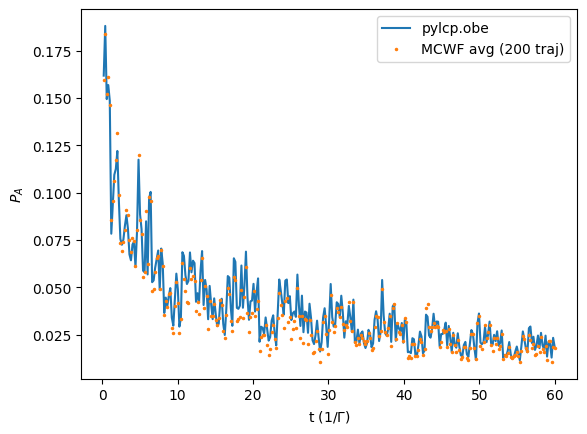

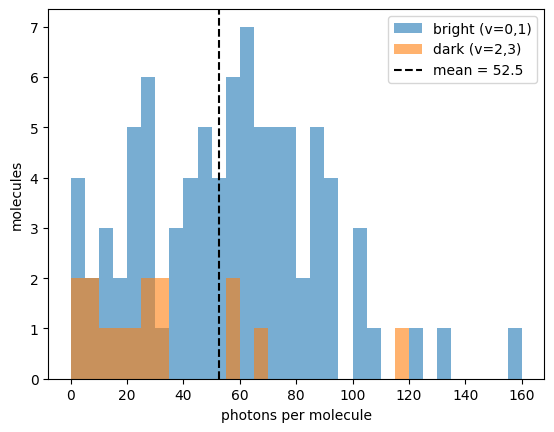

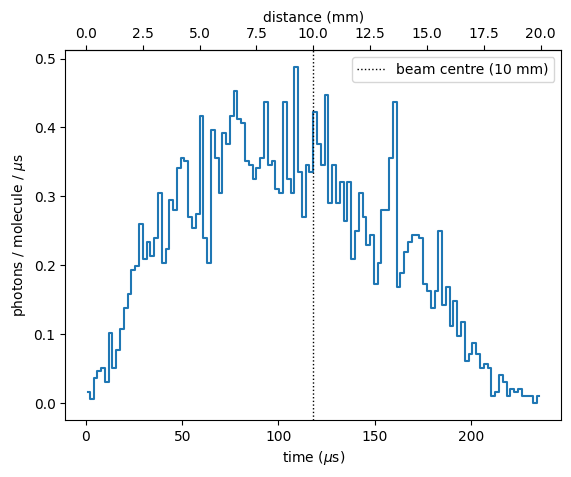

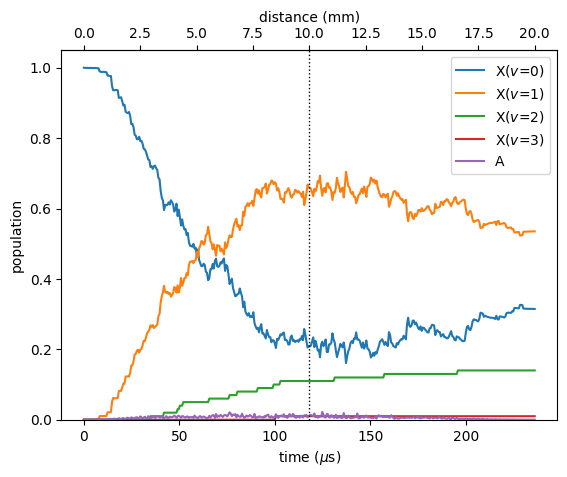


This took 4558.539449930191 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate (they predicted ~144 photons). The optical Bloch
equations (OBE) capture the coherences but only give the deterministic
ensemble average -- no per-molecule photon distribution.

The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.

Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""
import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.9307, 0.066, 0.003, 0.0003])
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat

V1_ON = True

P_p1 = 105e-3
P_v1 = 38e-3
s_p1 = power_to_s(P_p1, 4, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, 4, sigma_m, w_v1)
print(f"peak s per sideband: main {s_p1:.1f}, repump {s_v1:.1f}")
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 100e3
linewidth_v1_Hz = 100e3
gL_p1 = np.pi*linewidth_p1_Hz*tau*2   # 2*pi*FWHM * tau ... phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau*2

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_max, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    for delta in deltas:
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 84.7/v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            if V1_ON:
                if v >= 2:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 170 m/s = 0.17 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main 15.1, repump 0.0
P1 power 0.105 W
V1 power 0 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)

rate-equation reference: 14.4 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0130 (peak P_A ~ 0.188)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 11.8
  20/100: running mean = 13.1
  30/100: running mean = 12.1
  40/100: running mean = 12.3
  50/100: running mean = 15.1
  60/100: running mean = 14.4
  70/100: running mean = 16.1
  80/100: running mean = 15.1
  90/100: running mean = 15.5
  100/100: running mean = 15.1

--- MCWF photon statistics ---
mean photons/molecule: 15.1 +/- 1.4
std / median / max:    13.6 / 10 / 66
(rate equations gave 14.4 -- coherent dark states reduce this by x1.0)
fraction ending in X(v=0): 0.06, <photons|v=0> = 9.7
fraction ending in X(v=1): 0.88, <photons|v=1> = 15

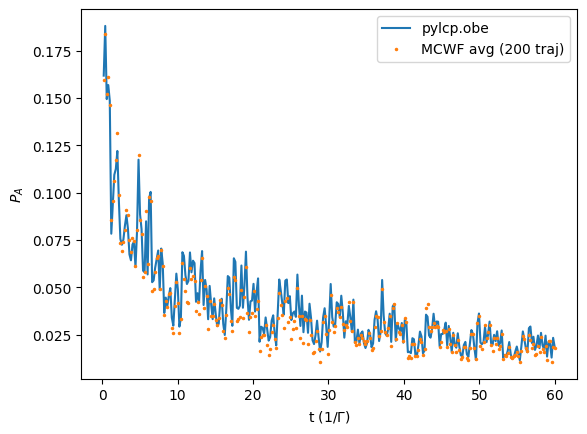

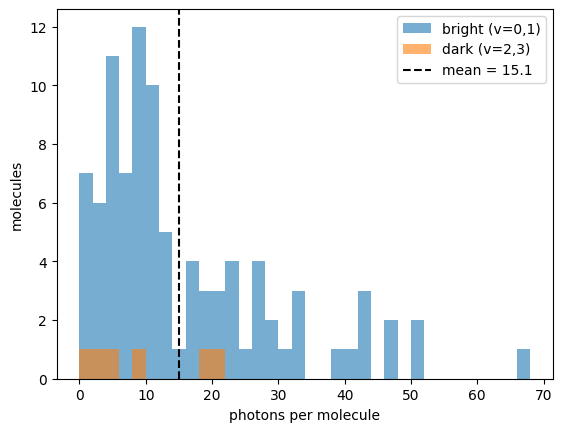

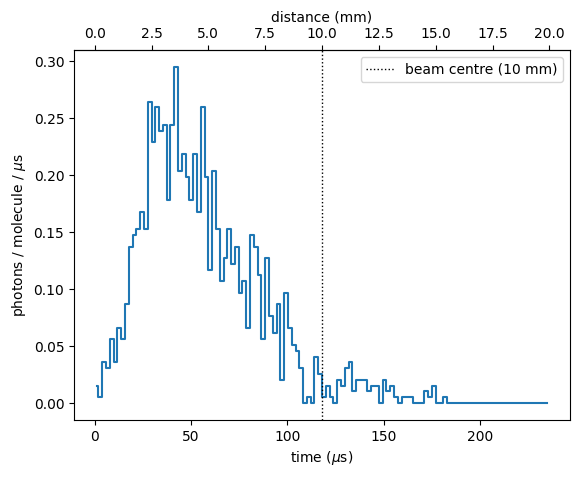

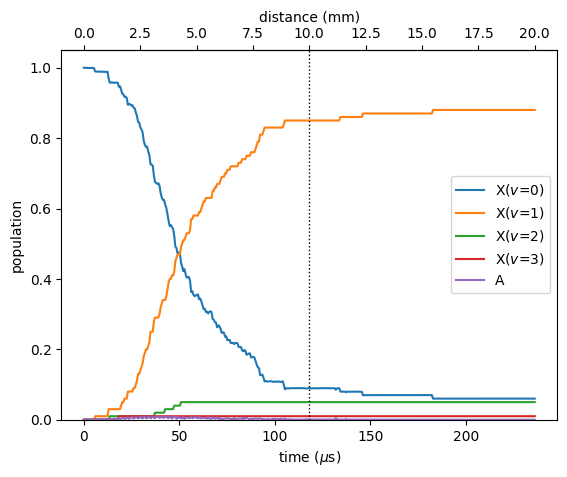


This took 1163.0698812007904 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate (they predicted ~144 photons). The optical Bloch
equations (OBE) capture the coherences but only give the deterministic
ensemble average -- no per-molecule photon distribution.

The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.

Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""
import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.9307, 0.066, 0.003, 0.0003])
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat

V1_ON = False

P_p1 = 105e-3
P_v1 = 0
s_p1 = power_to_s(P_p1, 4, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, 4, sigma_m, w_v1)
print(f"peak s per sideband: main {s_p1:.1f}, repump {s_v1:.1f}")
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 100e3
linewidth_v1_Hz = 100e3
gL_p1 = np.pi*linewidth_p1_Hz*tau*2   # 2*pi*FWHM * tau ... phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau*2

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_max, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    for delta in deltas:
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 84.7/v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            if V1_ON:
                if v >= 2:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 170 m/s = 0.17 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main 15.1, repump 6.0
P1 power 0.105 W
V1 power 0.038 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)

rate-equation reference: 286.3 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0130 (peak P_A ~ 0.188)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 80.5
  20/100: running mean = 89.8
  30/100: running mean = 99.1
  40/100: running mean = 103.2
  50/100: running mean = 104.9
  60/100: running mean = 111.1
  70/100: running mean = 112.2
  80/100: running mean = 110.2
  90/100: running mean = 110.5
  100/100: running mean = 107.6

--- MCWF photon statistics ---
mean photons/molecule: 107.6 +/- 6.1
std / median / max:    61.3 / 110 / 214
(rate equations gave 286.3 -- coherent dark states reduce this by x2.7)
fraction ending in X(v=0): 0.18, <photons|v=0> = 115.7
fraction ending in X(v=1): 0.48, 

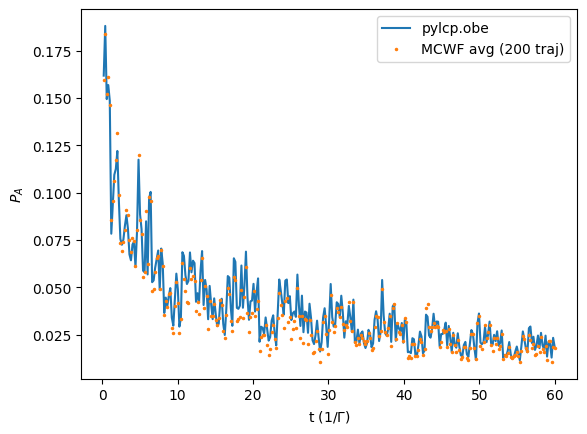

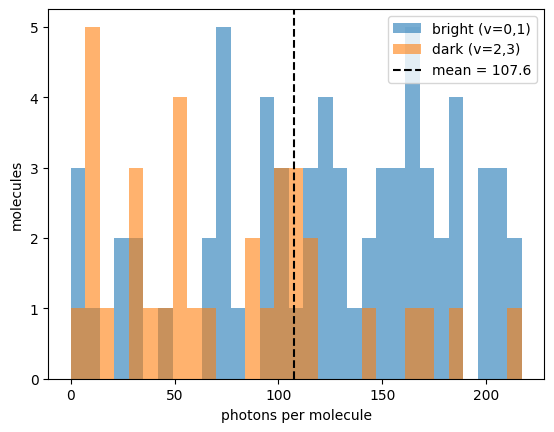

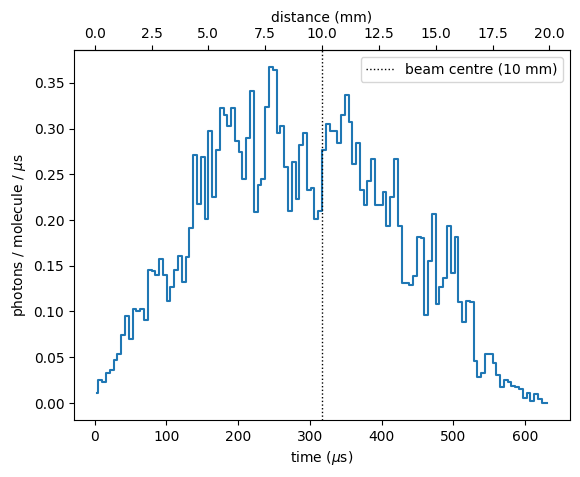

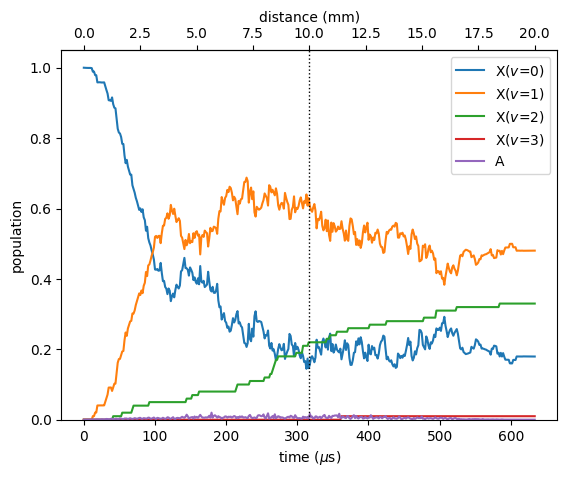


This took 10784.791373252869 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate (they predicted ~144 photons). The optical Bloch
equations (OBE) capture the coherences but only give the deterministic
ensemble average -- no per-molecule photon distribution.

The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.

Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""
import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.9307, 0.066, 0.003, 0.0003])
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat

V1_ON = True

P_p1 = 105e-3
P_v1 = 38e-3
s_p1 = power_to_s(P_p1, 4, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, 4, sigma_m, w_v1)
print(f"peak s per sideband: main {s_p1:.1f}, repump {s_v1:.1f}")
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 100e3
linewidth_v1_Hz = 100e3
gL_p1 = np.pi*linewidth_p1_Hz*tau*2   # 2*pi*FWHM * tau ... phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau*2

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_max, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    for delta in deltas:
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 31.56/v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            if V1_ON:
                if v >= 2:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 170 m/s = 0.17 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main 15.1, repump 0.0
P1 power 0.105 W
V1 power 0.0 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)

rate-equation reference: 14.4 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0130 (peak P_A ~ 0.188)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 16.6
  20/100: running mean = 19.6
  30/100: running mean = 17.7
  40/100: running mean = 16.7
  50/100: running mean = 16.3
  60/100: running mean = 16.6
  70/100: running mean = 16.4
  80/100: running mean = 15.5
  90/100: running mean = 15.9
  100/100: running mean = 15.5

--- MCWF photon statistics ---
mean photons/molecule: 15.5 +/- 1.6
std / median / max:    16.3 / 10 / 96
(rate equations gave 14.4 -- coherent dark states reduce this by x0.9)
fraction ending in X(v=0): 0.03, <photons|v=0> = 5.7
fraction ending in X(v=1): 0.95, <photons|v=1> = 

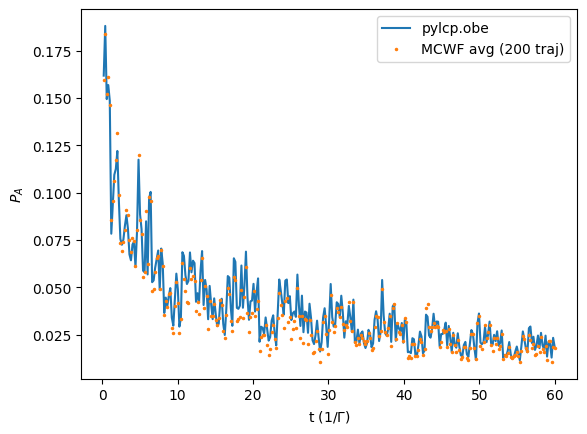

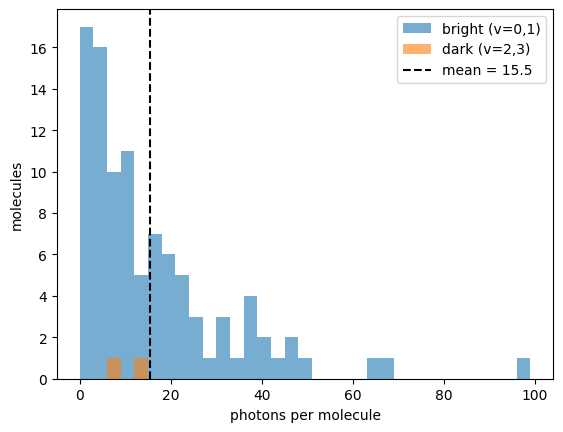

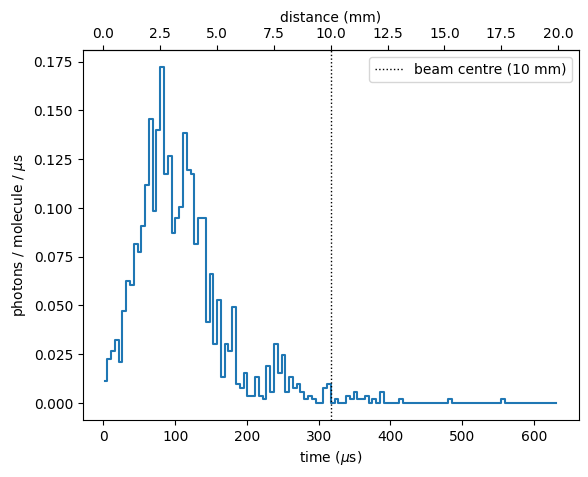

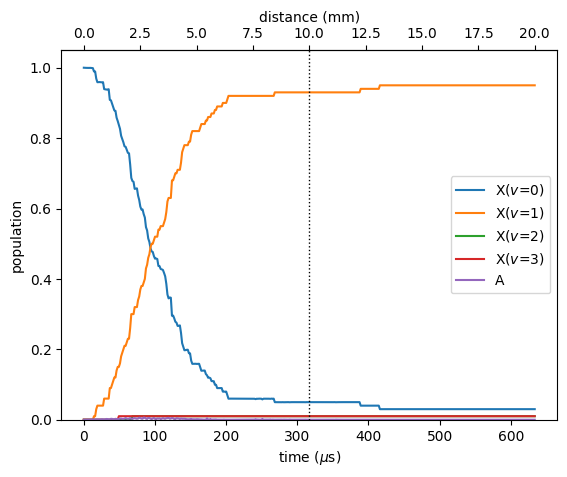


This took 2242.2577159404755 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate (they predicted ~144 photons). The optical Bloch
equations (OBE) capture the coherences but only give the deterministic
ensemble average -- no per-molecule photon distribution.

"""
import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.9307, 0.066, 0.003, 0.0003])
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat

V1_ON = False

P_p1 = 105e-3
P_v1 = 0e-3
s_p1 = power_to_s(P_p1, 4, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, 4, sigma_m, w_v1)
print(f"peak s per sideband: main {s_p1:.1f}, repump {s_v1:.1f}")
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 100e3
linewidth_v1_Hz = 100e3
gL_p1 = np.pi*linewidth_p1_Hz*tau*2   # 2*pi*FWHM * tau ... phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau*2

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_max, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    for delta in deltas:
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 31.56/v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            if V1_ON:
                if v >= 2:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    # dark vibrational state: population frozen in X(v)
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 170 m/s = 0.17 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
assert (np.sum(fcf, axis=0), 1.), "FCF factors don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = False

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 0e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 31.56/v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

<>:82: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:82: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<ipython-input-5-2c4501b9d32e>:82: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (np.sum(fcf, axis=0), 1.), "FCF factors don't sum to 1"


energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [0. 0. 0. 0.]
P1 power 0.105 W
V1 power 0.0 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  32.27  frac=0.500  s=30.3
  [1] F=0   E=   156.3 MHz  delta=   4.89  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=   3.92  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta=  -1.53  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  32.27  frac=0.500  s=30.3
  [1] F=0   E=   156.3 MHz  delta=   4.89  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=   3.92  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta=  -1.53  frac=0.250  s=15.1

rate-equation reference: 14.5 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0136 (peak P_A 

Restarted Python 3.9.5